# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PySonoGen, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
%load_ext autoreload
%autoreload 2


# 2. Define Matrix Transducer

In [2]:
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']


In [3]:
# Create transducer with elevation focus
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29

tx_pitch_mm = 0.3

tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm

tx_freq = 10 # MHz

directivity = 30 

c = 1540.0  # speed of sound in soft tissue (m/s)

Zeus_Matrix = Transducers.MatrixArrayTransducer(
        N_elem_x        = tx_N_elem_x,
        N_elem_y        = tx_N_elem_y,
        elem_width_mm   = tx_elem_width_mm,
        elem_height_mm  = tx_elem_height_mm,
        kerf_x_mm       = tx_kerf_x_mm,
        kerf_y_mm       = tx_kerf_y_mm,
        no_sub_x        = 2,
        no_sub_y        = 2,
        frequency_Hz    = tx_freq*1e6, 
        dir_angle_deg   = directivity
)

print(Zeus_Matrix)

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0672 seconds.
MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=2, no_sub_y=2, fc_Hz=10000000.0)


In [4]:
# Focalization spot
focus_mm =  np.array([0, 0, 8])  # mm [x, y, z]

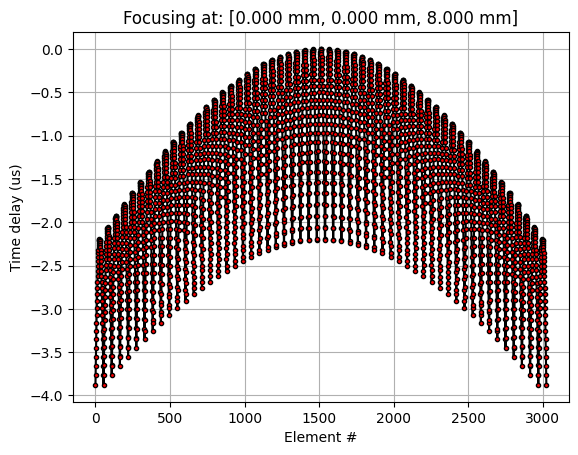

In [5]:
delays = Zeus_Matrix.compute_delays(focus_mm = focus_mm, plot = True)

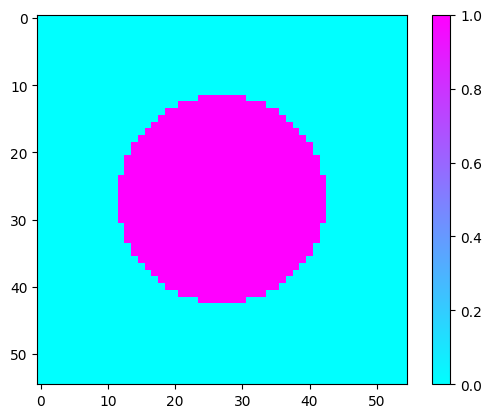

In [6]:
F_over_D = 1
apodization = Zeus_Matrix.compute_apodization(focus_mm = focus_mm, F_over_D = F_over_D, apodization_type='circular', plot = True)

In [7]:
Zeus_Matrix.show()  # Add this parameter

Widget(value='<iframe src="http://localhost:50739/index.html?ui=P_0x25f02ba5c10_0&reconnect=auto" class="pyvis…

# 3. Define field grid

In [8]:
import pysonogen
from pysonogen import pyfield


In [9]:
Zeus_Matrix_mesh = Zeus_Matrix.get_mesh()

In [10]:
Matrix_field = pyfield.PyField(Zeus_Matrix)

Successfully initialized PyField with 
 MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=2, no_sub_y=2, fc_Hz=10000000.0)


In [11]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.25+focus_mm[1], 0.25+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.025,
    "dy" : 0.025,
    "dz" : 0.05,
}

In [12]:
pressure_field, x, y, z = Matrix_field.compute_pressure_field(field_info_mm, inplace = False, normalize = False)


max_pressure = np.max(pressure_field)

Computing SIR for 18081 points and 12100 patches...
Total computation time: 42.7131 seconds.
Computing pressure field...
Performing FFT...
Frequency searched: 10000000.0 Hz. Found: 9980430.528375736 Hz


## 3.2. Plot 3D

Taking slice x_ind, y_ind, z_ind = 11/21, 11/21, 21/41


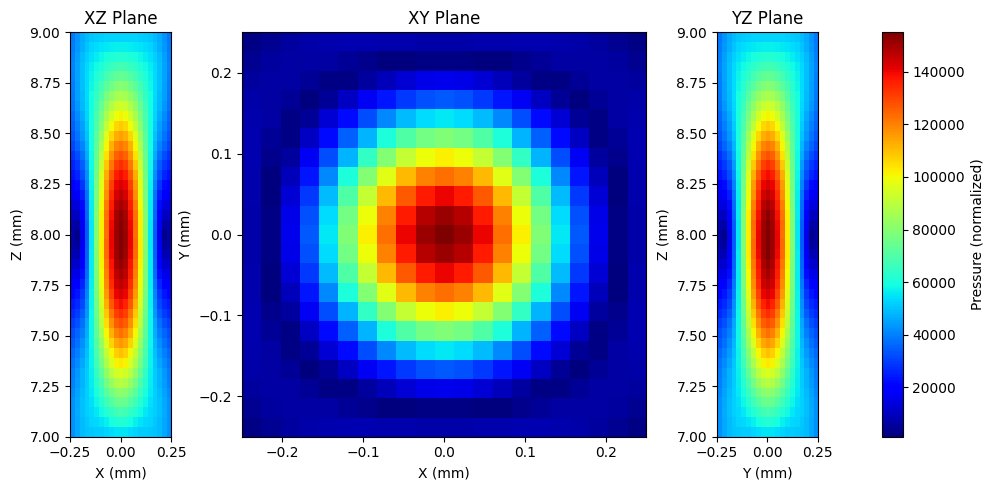

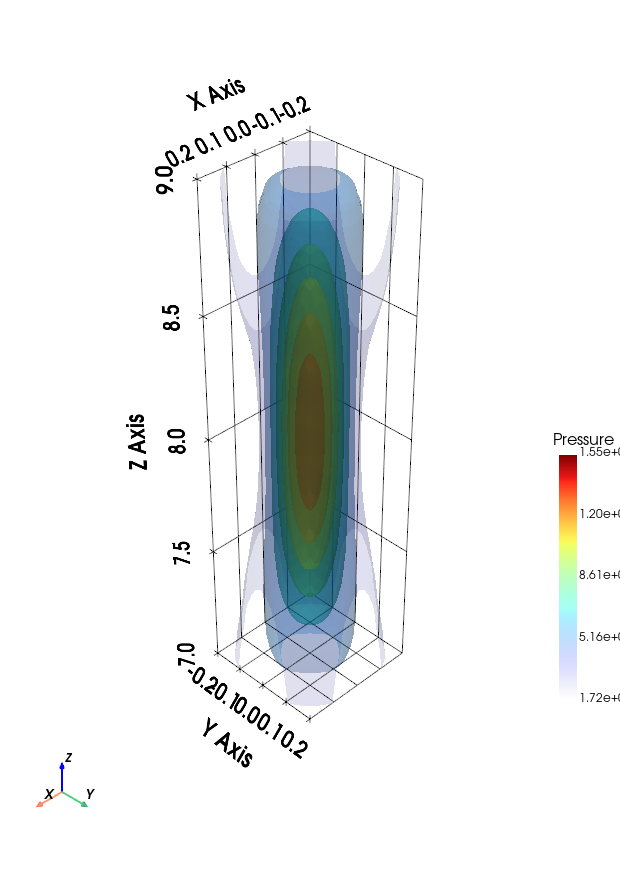

In [13]:
pysonogen.plot_field_planes(pressure_field, x, y, z,
                      figsize =(10, 5),  interpolation=None)

pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 880])


pressure_plotter.show(jupyter_backend='static')  # Add this parameter

In [14]:

Ensemble_plotter = pv.Plotter(notebook=False)

Ensemble_plotter = pysonogen.add_transducer_to_plotter(Ensemble_plotter, Zeus_Matrix_mesh)
Ensemble_plotter = pysonogen.add_pressure_to_plotter(Ensemble_plotter, pressure_vol_mesh, plot_focal_spot=False )

Ensemble_plotter.add_axes()              # show XYZ axes
Ensemble_plotter.show_grid()             # show grid
Ensemble_plotter.camera.up = [0, 0, -1]  # set camera up direction
Ensemble_plotter.show()  # Add this parameter

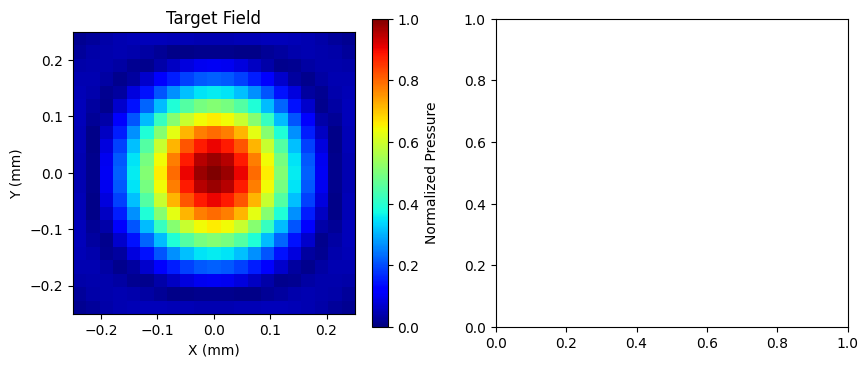

In [15]:
_, _, nz_target = pressure_field.shape
target = pressure_field[:,:,nz_target//2].squeeze()/ max_pressure

fig, ax = plt.subplots(1,2, figsize=(10, 4))
im1 = ax[0].imshow(target, extent=(x.min(), x.max(), y.min(), y.max()), vmin = 0, vmax = 1, cmap='jet')
ax[0].set_title("Target Field")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(im1, ax =ax[0], orientation='vertical', label='Normalized Pressure')

# 4. Work on patterned focalization

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
%load_ext autoreload
%autoreload 2

from torch_test import TorchField, create_simulation_grid
import torch

print(torch.__version__)
print(torch.version.cuda)
torch.cuda.is_available()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2.6.0+cu126
12.6


True

In [18]:
device_number = 0 # if you have multiple GPUs
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(device_number)}')
    device = torch.device(f'cuda:{device_number}')
else:
    print(f'No GPU available, running on CPU. May be slow.')
    device = torch.device('cpu')

Using GPU: NVIDIA GeForce RTX 4070 SUPER


In [19]:
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']


In [28]:
Zeus_Matrix = Transducers.Zeus_Matrix()

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0640 seconds.


In [29]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.25+focus_mm[1], 0.25+focus_mm[1]],
    "z_extent" : [-0.05+focus_mm[2], 0.05+focus_mm[2]],
    "dx" : 0.025,
    "dy" : 0.025,
    "dz" : 0.05,
}

x, y, z, points = create_simulation_grid(field_info_mm)

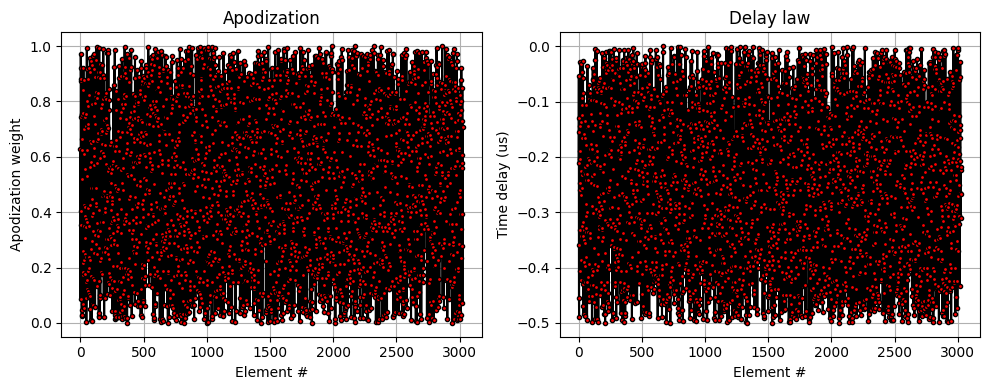

In [30]:
init_apod = np.random.rand(Zeus_Matrix.n_elem_x*Zeus_Matrix.n_elem_y)
init_delay = np.random.rand(Zeus_Matrix.n_elem_x*Zeus_Matrix.n_elem_y)

# Compute delays based on the speed of sound in soft tissue
init_delay = (init_delay.min()- init_delay)/2*1e-6  # time delays for focusing

# optionally plot
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].plot(np.arange(Zeus_Matrix.n_elements), init_apod, 'k-', marker='o', markerfacecolor='r', ms = 3)
ax[0].set_xlabel("Element #")
ax[0].set_ylabel("Apodization weight")
ax[0].set_title("Apodization")
ax[0].grid(True)
ax[1].plot(np.arange(Zeus_Matrix.n_elements), init_delay*1e6, 'k-', marker='o', markerfacecolor='r', ms = 3)
ax[1].set_xlabel("Element #")
ax[1].set_ylabel("Time delay (us)")
ax[1].set_title("Delay law")
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [24]:
points.shape

(1323, 3)

In [31]:

# Assume you have MatrixArrayTransducer imported and instantiated
trans = Transducers.Zeus_Matrix()
# Wrap in TorchField
model = TorchField(trans, device=device)
# Example field points: center line

# Define optimizer on apod & delays
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)


MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0615 seconds.


In [32]:

amp = model(points)  # forward pass
# To optimize, compute a loss: e.g. target focus at index 50

OutOfMemoryError: CUDA out of memory. Tried to allocate 166.00 MiB. GPU 0 has a total capacity of 11.99 GiB of which 0 bytes is free. Of the allocated memory 74.13 GiB is allocated by PyTorch, and 41.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

loss = nn.MSELoss()(amp, target)
loss.backward()
optimizer.step()
print('Loss:', loss.item())

In [ ]:
nx_target, ny_target, nz_target = pressure_field.shape
result = focal_plane / max_pressure


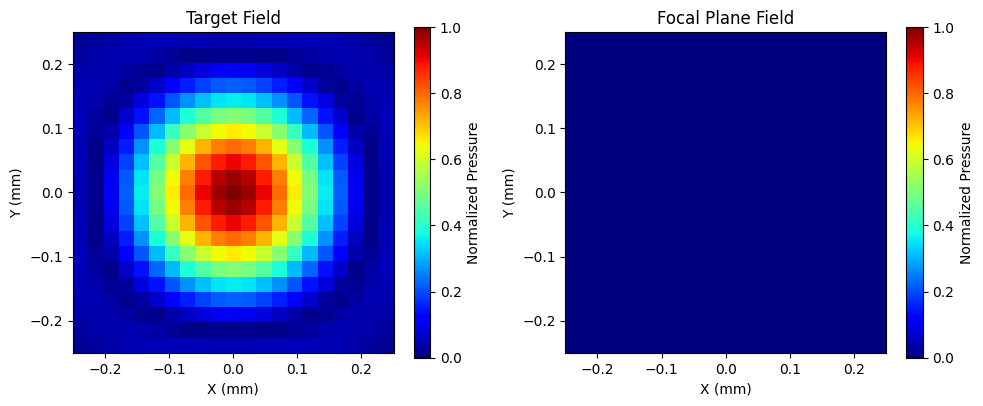

In [82]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
im1 = ax[0].imshow(target, extent=(x.min(), x.max(), y.min(), y.max()), vmin = 0, vmax = 1, cmap='jet')
ax[0].set_title("Target Field")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(im1, ax =ax[0], orientation='vertical', label='Normalized Pressure')

im2 = ax[1].imshow(result, extent=(x.min(), x.max(), y.min(), y.max()), vmin = 0, vmax = 1, cmap='jet')
ax[1].set_title("Focal Plane Field")
ax[1].set_xlabel("X (mm)")
ax[1].set_ylabel("Y (mm)")
fig.colorbar(im2, ax =ax[1], orientation='vertical', label='Normalized Pressure')

plt.tight_layout()
plt.show()